## How many people have I seen?
This is being done in 2 ways. The first is from a "direct" plane of view vs seeing something from a distance. 

The average person spends about 2.4 hours outside per day — commuting, errands, recreation — that's exactly 10% of a 24-hour period. NYC-specific context makes it feel right too: Bed-Stuy's total population from your data is roughly 168,000. At 10%, that's ~16,800 people on streets at any moment, across ~300 blocks — about 56 people per block. That matches what a typical residential Brooklyn block feels like on a weekday afternoon.

The honest caveat is that 10% is a daily average — it compresses a lot of variation:

Peak commute hours (8-9am, 5-7pm): closer to 20-25%
Weekend afternoon: 15-20%
Late night: near 0%

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt

BUFFER_CRS   = 2263
WORKING_CRS  = 4326

BUFFERS = {
    "direct":        30,   # ft — buildings lining the streets you walked
    "field_of_view": 250,  # ft — visible from intersections / down the block
}

# Load inputs
pluto = gpd.read_file("outputs/population_by_taxlot_bedstuy.geojson")
path  = gpd.read_file("/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/Data/Walkpath.geojson").to_crs(BUFFER_CRS)

# Reproject pluto to feet for the spatial ops
pluto_ft  = pluto.to_crs(BUFFER_CRS)
total_pop = pluto["est_pop_per_lot"].sum()

# Run both buffers
results = {}
for label, dist in BUFFERS.items():
    buffered    = path.buffer(dist).union_all()
    intersected = pluto_ft[pluto_ft.geometry.intersects(buffered)]
    pop_seen    = intersected["est_pop_per_lot"].sum()
    results[label] = {
        "pop_seen":          pop_seen,
        "pct_seen":          pop_seen / total_pop * 100,
        "lots_intersected":  len(intersected),
        "buffered_geom":     buffered,
    }

# Print results
for label, r in results.items():
    print(f"\n{label.upper()}")
    print(f"  Lots intersected : {r['lots_intersected']}")
    print(f"  Population seen  : {r['pop_seen']:.0f}")
    print(f"  % of Bed-Stuy    : {r['pct_seen']:.1f}%")


DIRECT
  Lots intersected : 150
  Population seen  : 3330
  % of Bed-Stuy    : 2.0%

FIELD_OF_VIEW
  Lots intersected : 1201
  Population seen  : 25788
  % of Bed-Stuy    : 15.3%


## Two ways of viewing

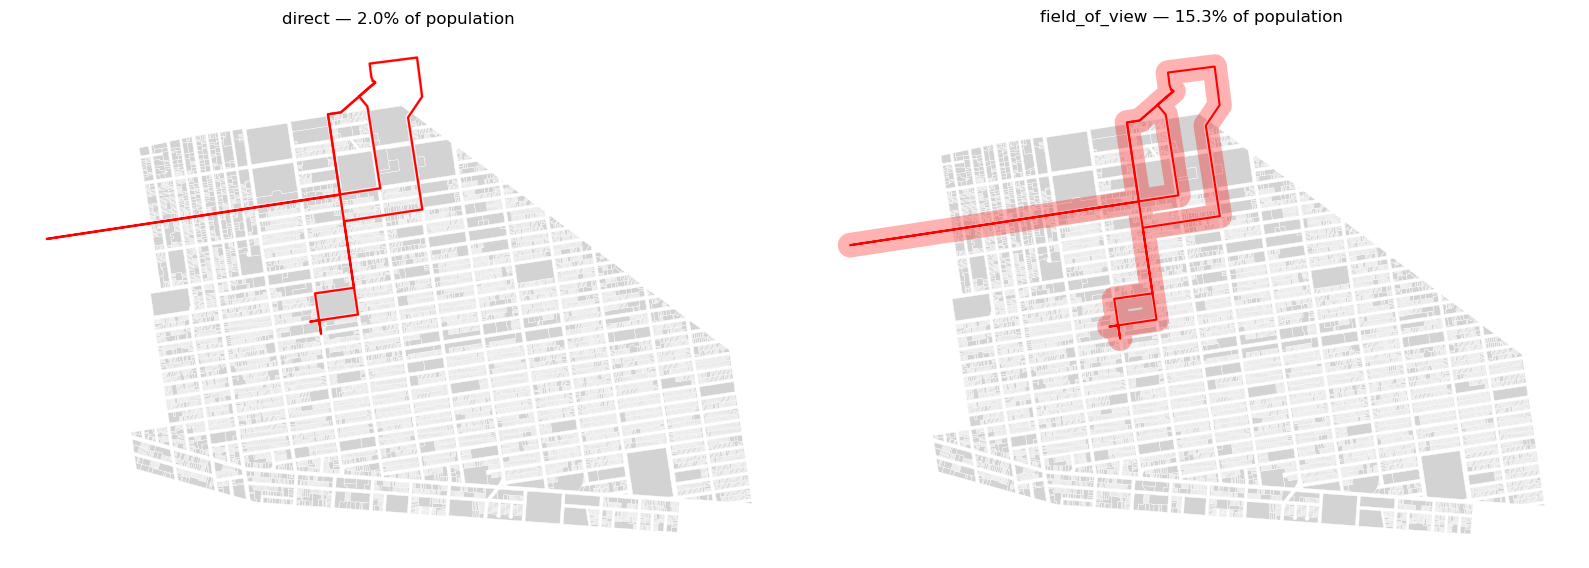

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (label, r) in zip(axes, results.items()):
    pluto.to_crs(WORKING_CRS).plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.3)
    gpd.GeoSeries([r["buffered_geom"]], crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
        ax=ax, color="red", alpha=0.3
    )
    path.to_crs(WORKING_CRS).plot(ax=ax, color="red", linewidth=1.5)
    ax.set_title(f"{label} — {r['pct_seen']:.1f}% of population")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
fig.savefig("outputs/WalkViews.png", dpi=150, bbox_inches="tight")

In [14]:
OUTDOOR_RATE = 0.10

print(f"Total Bed-Stuy population (estimated): {total_pop:,.0f}")
print(f"People on streets at any moment (10%): {total_pop * OUTDOOR_RATE:,.0f}")
print()

for label, r in results.items():
    encountered = r["pop_seen"] * OUTDOOR_RATE
    print(f"{label.upper()}")
    print(f"  Assumption 1 — seeing a building = seeing a person")
    print(f"    Population in range : {r['pop_seen']:,.0f} ({r['pct_seen']:.1f}%)")
    print(f"  Assumption 2 — 10% of residents are outside")
    print(f"    People encountered  : {encountered:,.0f} ({encountered / total_pop * 100:.2f}%)")
    print()

Total Bed-Stuy population (estimated): 168,572
People on streets at any moment (10%): 16,857

DIRECT
  Assumption 1 — seeing a building = seeing a person
    Population in range : 3,330 (2.0%)
  Assumption 2 — 10% of residents are outside
    People encountered  : 333 (0.20%)

FIELD_OF_VIEW
  Assumption 1 — seeing a building = seeing a person
    Population in range : 25,788 (15.3%)
  Assumption 2 — 10% of residents are outside
    People encountered  : 2,579 (1.53%)



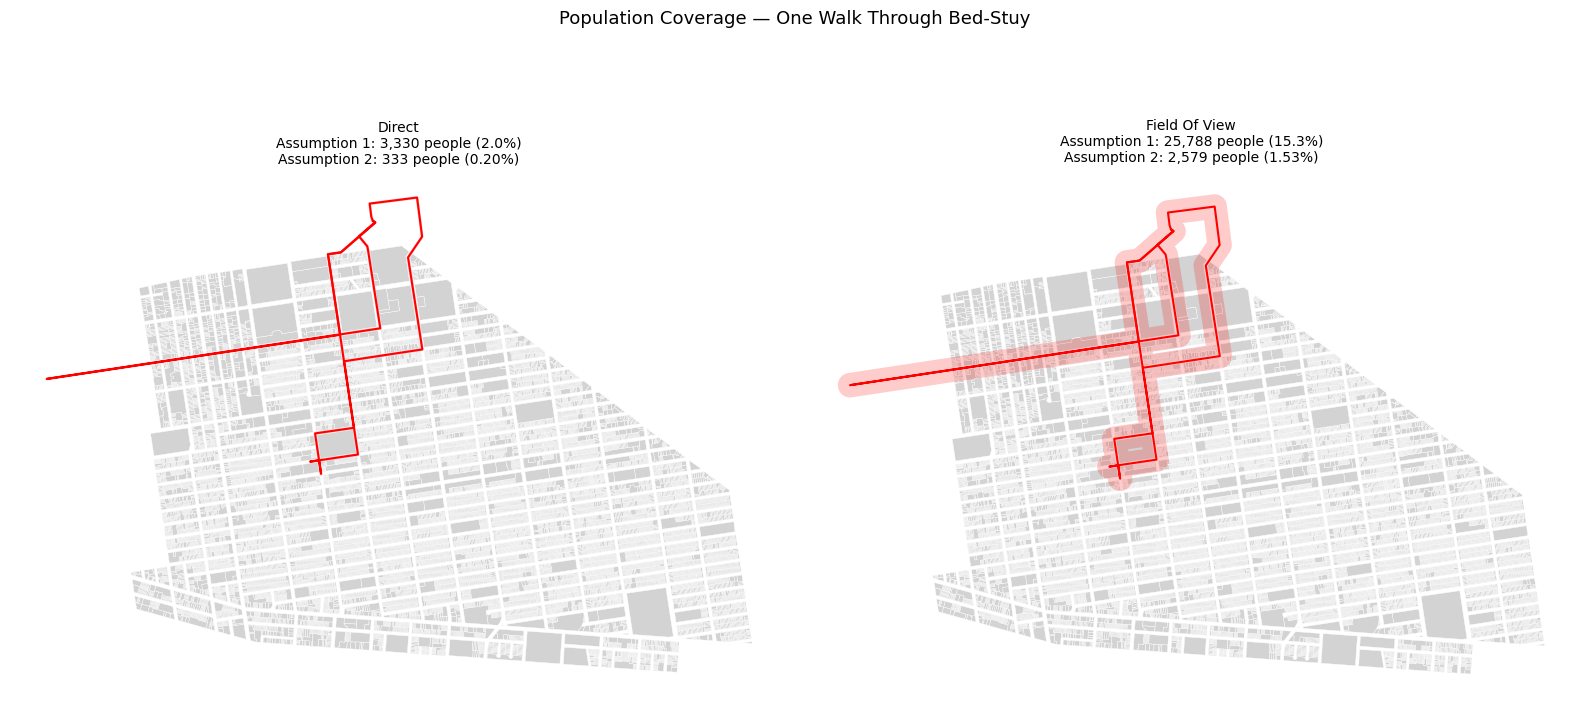

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (label, r) in zip(axes, results.items()):
    encountered = r["pop_seen"] * OUTDOOR_RATE

    pluto.to_crs(WORKING_CRS).plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.3)
    gpd.GeoSeries([r["buffered_geom"]], crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
        ax=ax, color="red", alpha=0.2
    )
    path.to_crs(WORKING_CRS).plot(ax=ax, color="red", linewidth=1.5)

    ax.set_title(
        f"{label.replace('_', ' ').title()}\n"
        f"Assumption 1: {r['pop_seen']:,.0f} people ({r['pct_seen']:.1f}%)\n"
        f"Assumption 2: {encountered:,.0f} people ({encountered / total_pop * 100:.2f}%)",
        fontsize=10
    )
    ax.axis("off")

plt.suptitle("Population Coverage — One Walk Through Bed-Stuy", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
fig.savefig("outputs/Population Coverage — One Walk Through Bed-Stuy.png", dpi=150, bbox_inches="tight")

Ok but there is some sloppiness in these assumptions. That statistic is built off of people being out of their house but not on the street. 

In [17]:
RATES = {
    "ATUS (10% — time use survey proxy)": 0.10,
    "Field Observation (assumed ~2%)":    0.02,
}

BUFFERS = {
    "direct":        50,
    "field_of_view": 250,
}

print(f"Total Bed-Stuy population: {total_pop:,.0f}\n")

for rate_label, rate in RATES.items():
    for buffer_label, dist in BUFFERS.items():
        buffered    = path.to_crs(BUFFER_CRS).buffer(dist).union_all()
        intersected = pluto_ft[pluto_ft.geometry.intersects(buffered)]
        pop_seen    = intersected["est_pop_per_lot"].sum()
        encountered = pop_seen * rate
        print(f"{rate_label} | {buffer_label}")
        print(f"  Lots in range      : {len(intersected):,}")
        print(f"  Population in range: {pop_seen:,.0f} ({pop_seen / total_pop * 100:.1f}%)")
        print(f"  People encountered : {encountered:,.0f} ({encountered / total_pop * 100:.2f}%)")
        print()

Total Bed-Stuy population: 168,572

ATUS (10% — time use survey proxy) | direct
  Lots in range      : 488
  Population in range: 15,633 (9.3%)
  People encountered : 1,563 (0.93%)

ATUS (10% — time use survey proxy) | field_of_view
  Lots in range      : 1,201
  Population in range: 25,788 (15.3%)
  People encountered : 2,579 (1.53%)

Field Observation (assumed ~2%) | direct
  Lots in range      : 488
  Population in range: 15,633 (9.3%)
  People encountered : 313 (0.19%)

Field Observation (assumed ~2%) | field_of_view
  Lots in range      : 1,201
  Population in range: 25,788 (15.3%)
  People encountered : 516 (0.31%)



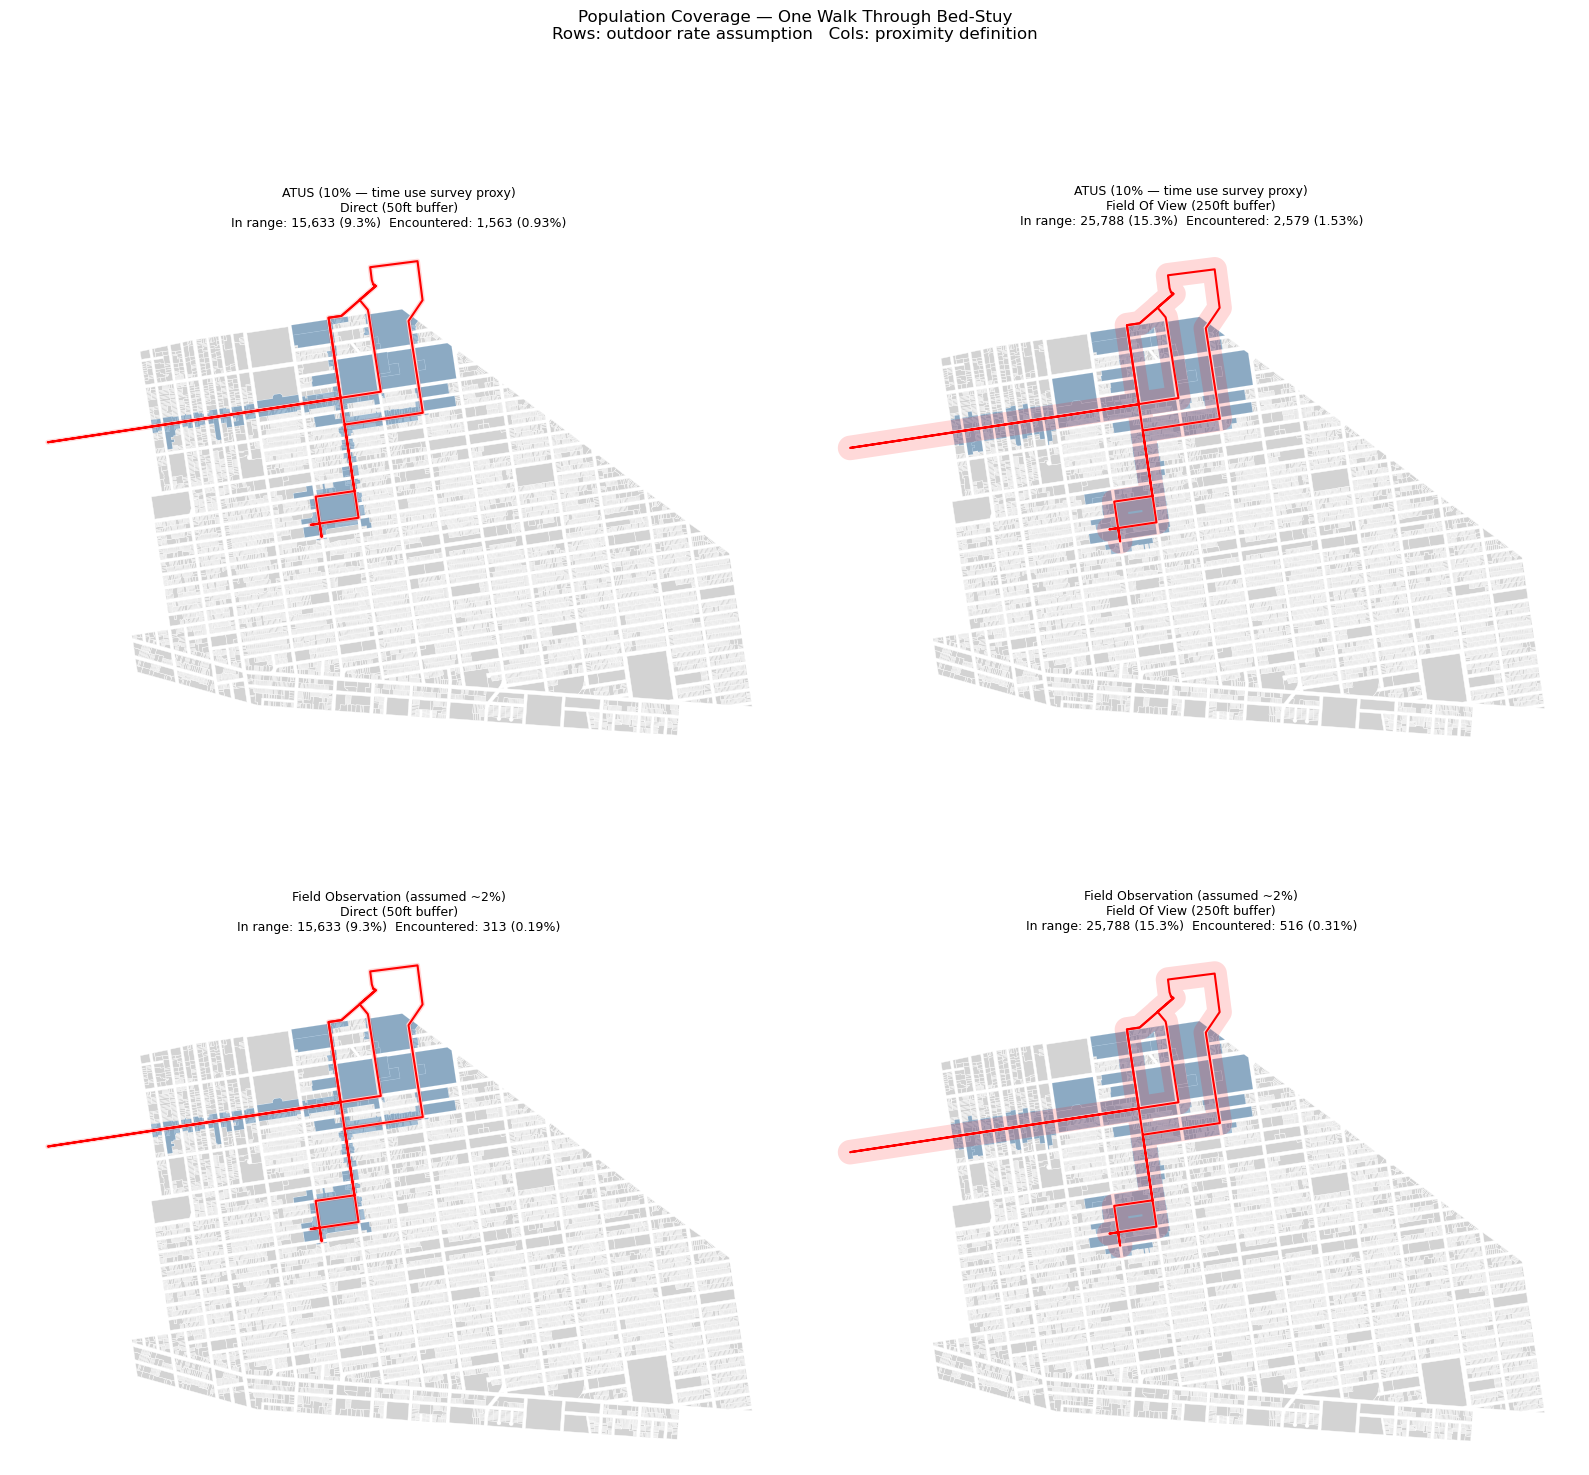

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

rate_labels   = list(RATES.items())
buffer_labels = list(BUFFERS.items())

for row, (rate_label, rate) in enumerate(rate_labels):
    for col, (buffer_label, dist) in enumerate(buffer_labels):
        ax = axes[row][col]

        buffered    = path.to_crs(BUFFER_CRS).buffer(dist).union_all()
        intersected = pluto_ft[pluto_ft.geometry.intersects(buffered)]
        pop_seen    = intersected["est_pop_per_lot"].sum()
        encountered = pop_seen * rate

        # Base layers
        pluto_ft.to_crs(WORKING_CRS).plot(
            ax=ax, color="lightgray", edgecolor="white", linewidth=0.3
        )
        intersected.to_crs(WORKING_CRS).plot(
            ax=ax, color="steelblue", alpha=0.5, edgecolor="none"
        )
        gpd.GeoSeries([buffered], crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
            ax=ax, color="red", alpha=0.15
        )
        path.to_crs(WORKING_CRS).plot(ax=ax, color="red", linewidth=1.5)

        ax.set_title(
            f"{rate_label}\n"
            f"{buffer_label.replace('_', ' ').title()} ({dist}ft buffer)\n"
            f"In range: {pop_seen:,.0f} ({pop_seen / total_pop * 100:.1f}%)  "
            f"Encountered: {encountered:,.0f} ({encountered / total_pop * 100:.2f}%)",
            fontsize=9
        )
        ax.axis("off")

plt.suptitle(
    "Population Coverage — One Walk Through Bed-Stuy\n"
    "Rows: outdoor rate assumption   Cols: proximity definition",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

In [19]:
fig.savefig("outputs/coverage_2x2.png", dpi=150, bbox_inches="tight")